<a href="https://colab.research.google.com/github/salvadeharo10/RL_DHBV/blob/main/MonteCarloTodasLasVisitas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Asignatura**: Extensiones de Machine Learning, 2024/2025

**Alumnos**:<br>
- Salvador de Haro Orenes (salvadorde.haroo@um.es)
- Jose María Belmonte Martínez (josemaria.belmontem@um.es)
- Miguel Vidal García (miguel.vidalg@um.es)

**Máster de Inteligencia Artificial**

**Facultad de Informática**

![](https://www.um.es/image/layout_set_logo?img_id=175281&t=1726728636242)

**Universidad de Murcia**

![](https://www.um.es/o/um-lr-principal-um-home-theme/images/logo-um.png)

# PRÁCTICA 2: APRENDIZAJE EN ENTORNOS COMPLEJOS

En esta práctica se explorará el aprendizaje en entornos complejos, donde las decisiones deben tomarse en un contexto dinámico. A diferencia del bandido de k-brazos, que estudia la exploración y explotación en un entorno estático, aquí modelará el problema como un Proceso de Decisión de Markov (MDP) con recompensas que pueden ser estocásticas.

El reto en estos entornos es que no se conoce la dinámica del mundo (las transiciones entre estados y las recompensas exactas), por lo que el aprendizaje debe basarse en la experiencia del agente al interactuar con el entorno. Para ello, se usarán técnicas de Aprendizaje por Refuerzo (RL) que siguen el siguiente ciclo:

1. Observar el estado actual del entorno.
2. Tomar una acción según una política.
3. Recibir una recompensa y observar el nuevo estado.
4. Actualizar la política con base en la recompensa obtenida.
5. Repetir hasta alcanzar un estado terminal.

Se utilizará Gymnasium (una plataforma de simulación de entornos RL) y diferentes algoritmos de aprendizaje por refuerzo para entrenar agentes capaces de tomar decisiones óptimas en distintos escenarios.

Por tanto, los principales objetivos de la práctica son:
- Comprender la interacción entre un agente y su entorno en Gymnasium.
- Implementar y modificar algoritmos de aprendizaje por refuerzo para mejorar la toma de decisiones.
- Comparar diferentes enfoques: métodos tabulares, aprendizaje con aproximaciones y exploración de recompensas.
- Visualizar la evolución del aprendizaje a través de métricas y gráficos.

## Preparación del Entorno

La preparación consta de las siguientes partes:
- **Instalación de Dependencias**: Se instalan las librerías necesarias para utilizar el entorno `gymnasium` para la simulación, con el objetivo de crear un ambiente controlado para que el agente pueda interactuar.
- **Importación de Librerías**: Se importan las bibliotecas necesarias como `numpy` para el manejo de matrices y `matplotlib` para la visualización de los resultados.

- **Importación del Entorno "FrozenLake"**:
Se cargan dos versiones del entorno "FrozenLake": una de 4x4 y otra de 8x8. Ambas versiones no son resbaladizas, lo que facilita la comprensión de los resultados, dado que el entorno resbaladizo podría dificultar la comprensión inicial del aprendizaje.

- **Configurar semilla para reproducibilidad de resultados.**

In [ ]:
#@title Instalar algunas librerias
!pip install 'gym[box2d]==0.20.0'

## Instalación de algunos paquetes.
#!apt-get update
## Para usar gymnasium[box2d]
#!apt install swig
#!pip install gymnasium[box2d]
!apt-get update

# Para visualizar en colab https://medium.com/@coldstart_coder/visually-rendering-python-gymnasium-in-jupyter-notebooks-4413e4087a0f
!apt-get install -y python-opengl ffmpeg
!apt-get install --upgrade cmake

# Para usar gymnasium[box2d]
!apt install swig xvfb
!pip install -U  pyvirtualdisplay
!pip install gymnasium gymnasium[box2d]

In [ ]:
#@title Importar librerias
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym
from scipy.ndimage import uniform_filter1d

In [ ]:
#@title Creacion de entornos Gymnasium
name = 'FrozenLake-v1'
desc=["SFFF", "HHFH", "FFFH", "HFFG"]
env4 = gym.make(name, is_slippery=False, map_name="4x4", render_mode="rgb_array", desc=desc) # No resbaladizo para entender mejor los resultados.
env8 = gym.make(name, is_slippery=False, map_name="8x8", render_mode="rgb_array") # No resbaladizo para entender mejor los resultados.

## PARTE A) CONOCER ENTORNO GYMNASIUM

El primer paso será familiarizarse con Gymnasium, una plataforma que permite simular entornos para probar distintos algoritmos de aprendizaje.

Como punto de partida, el profesor proporciona un código base que muestra cómo generar episodios y diseñar agentes de aprendizaje. Sin embargo, este código no usa Monte Carlo, por lo que será necesario modificarlo para implementar la versión correcta del algoritmo.

Las tareas a realizar, por tanto, son las siguientes:
- Modificar el código base para que el agente aprenda correctamente usando Monte Carlo.
- Construir un agente que cumpla con las especificaciones de Gymnasium.
- Añadir una nueva gráfica que represente la evolución de la longitud de los episodios ($f(t) = len(episodio_t)$) y comentar por qué esta gráfica es útil para analizar el aprendizaje de un agente.

### A.1) Agente Monte Carlo con políticas epsilon-soft

En esta sección se implementará un agente de aprendizaje por refuerzo basado en Monte Carlo On-Policy. Este agente tiene la capacidad de aprender una política óptima mediante la acumulación de experiencia en episodios completos.

A diferencia de los métodos de programación dinámica, que requieren conocer la dinámica del entorno (matriz de transición y recompensas), los métodos de Monte Carlo aprenden directamente de la experiencia. Específicamente, este agente seguirá la estrategia **On-Policy**, lo que significa que la misma política que genera los episodios es la que se evalúa y mejora a lo largo del aprendizaje.

**Características principales del agente:**
- **Política ε-soft**: Para equilibrar exploración y explotación, el agente sigue una política ε-soft, en la que la mejor acción se selecciona con probabilidad $1-ϵ$, mientras que las demás acciones tienen una probabilidad pequeña de ser elegidas.
- **Actualización basada en episodios:** El algoritmo espera a que el episodio termine antes de actualizar los valores de acción $Q(s, a)$.
- **Promedio de retornos:** Se almacena un histórico de los retornos de cada par (estado, acción) para promediar los valores y lograr una estimación más precisa de $Q(s, a)$.
- **Decaimiento del parámetro $ϵ$:** Si está activado, el valor de ε se reduce gradualmente para fomentar la explotación a medida que el aprendizaje avanza.

In [ ]:
# @title Políticas del agente

# actions
LEFT, DOWN, RIGHT, UP = 0,1,2,3

# Política epsilon-soft. Se usa para el entrenamiento
def random_epsilon_greedy_policy(Q, epsilon, state, nA):
    pi_A = np.ones(nA, dtype=float) * epsilon / nA
    best_action = np.argmax(Q[state])
    pi_A[best_action] += (1.0 - epsilon)
    return pi_A

# Política epsilon-greedy a partir de una epsilon-soft
def epsilon_greedy_policy(Q, epsilon, state, nA):
    pi_A = random_epsilon_greedy_policy(Q, epsilon, state, nA)
    return np.random.choice(np.arange(nA), p=pi_A)

# Política Greedy a partir de los valones Q. Se usa para mostrar la solución.
def pi_star_from_Q(env, Q):
    done = False
    pi_star = np.zeros([env.observation_space.n, env.action_space.n])
    state, info = env.reset() # start in top-left, = 0
    actions = ""
    while not done:
        action = np.argmax(Q[state, :])
        actions += f"{action}, "
        pi_star[state,action] = action
        state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
    return pi_star, actions



def pi_star_from_Q_recordVideo(env, Q, video_folder="videos", num_episodes=5000):
    """ Ejecuta múltiples episodios usando Q y graba videos cada 1000 episodios. """

    for episode in range(0, num_episodes, 1000):  # Avanza de 1000 en 1000
        env = gym.wrappers.RecordVideo(env, video_folder=video_folder, episode_trigger=lambda eid: True)
        print(f"Grabando episodio {episode + 1}...")

        done = False
        pi_star = np.zeros([env.observation_space.n, env.action_space.n])
        state, info = env.reset()
        actions = f"Episodio {episode + 1}: "

        while not done:
            env.render()  # Renderiza el frame para grabarlo en video
            action = np.argmax(Q[state, :])
            actions += f"{action}, "
            pi_star[state, action] = action
            state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

        print(f"Episodio {episode + 1} completado.")
        env.close()  # Cierra para guardar el video correctamente

    return pi_star, actions

In [ ]:
# Clase MonteCarloOnPolicyAgent
class AgentMonteCarloOnPolicy:
    """
    Implementación de un agente de Aprendizaje por Refuerzo basado en Monte Carlo On-Policy.
    Aprende una política óptima a partir de episodios completos y actualiza la función de valor Q(s, a).
    """

    def __init__(self, env, gamma, epsilon, decay):
        """
        Inicializa el agente con los parámetros de entrenamiento.

        Parámetros:
        - env: entorno de Gymnasium donde se entrena el agente.
        - gamma: factor de descuento (γ), pondera la importancia de las recompensas futuras.
        - epsilon: parámetro de exploración para la política ε-soft.
        - decay: booleano, si es True, se reduce ε conforme avanza el entrenamiento.
        """
        self.env = env
        self.gamma = gamma
        self.epsilon = epsilon
        self.decay = decay

        # Tabla Q para almacenar los valores de estado-acción
        self.Q = np.zeros((self.env.observation_space.n, self.env.action_space.n))

        # Diccionario para almacenar los retornos de cada par (estado, acción)
        self.returns = {}


    def get_action(self, state, n):
        """
        Selecciona una acción siguiendo una política ε-soft.

        Parámetros:
        - state: estado actual del agente en el entorno.
        - n: número de episodios transcurridos (para el decaimiento de ε si está activado).

        Retorna:
        - La acción seleccionada según la política ε-soft.
        """
        # Si el decaimiento de ε está activado, se reduce su valor conforme avanza el entrenamiento
        if self.decay:
            self.epsilon = min(1.0, 1000.0 / (n + 1))

        # Inicializamos una distribución uniforme de probabilidades para todas las acciones
        action_probabilities = np.ones(self.env.action_space.n) * (self.epsilon / self.env.action_space.n)

        # Se identifica la mejor acción (aquella con el mayor valor Q)
        best_action = np.argmax(self.Q[state])

        # Se aumenta la probabilidad de la mejor acción con (1 - ε)
        action_probabilities[best_action] += (1 - self.epsilon)

        # Se elige una acción según la distribución de probabilidades calculada
        return np.random.choice(self.env.action_space.n, p=action_probabilities)


    def update(self, episode):
        """
        Actualiza la tabla Q(s, a) usando Monte Carlo On-Policy.

        Parámetros:
        - episode: lista de tuplas (estado, acción, recompensa) que conforman un episodio completo.
        """
        # Extraemos los estados, acciones y recompensas del episodio
        states, actions, rewards = zip(*episode)

        # Inicializamos el retorno total G
        G = 0

        # Recorremos el episodio en orden inverso
        for t in range(len(episode) - 1, -1, -1):
            state, action, reward = episode[t]

            # Se calcula el retorno acumulado desde el estado actual hasta el final del episodio
            G = self.gamma * G + reward

            # Solo actualizamos el valor de (state, action) si es la primera vez que aparece en el episodio
            if (state, action) not in [(x[0], x[1]) for x in episode[:t]]:

                # Si el par (state, action) no está en el diccionario de retornos, se inicializa
                if (state, action) not in self.returns:
                    self.returns[(state, action)] = []

                # Se almacena el retorno obtenido en la lista de retornos del par (state, action)
                self.returns[(state, action)].append(G)

                # Se actualiza Q(s, a) con el promedio de los retornos acumulados para este par
                self.Q[state, action] = np.mean(self.returns[(state, action)])

### **A.2) Representaciones Gráficas**

Para evaluar el rendimiento del agente, se representará la función: $$f(t)=\frac{\sum_{i=1}^t R_i}{t}$$ para $t=1,2,\ldots, NumeroEpisodios$

La justificación es la siguiente. Sabemos que el retorno en el estado inicial puede ser 1 (si llega al estado objetivo) o 0 (sin descuento). Si se divide por el número de episodios ejecutados, se obtiene el porcentaje de recompensas positivas obtenidas. Dicho de otra forma, esta función nos dirá cuántas veces el agente ha alcanzado el estado terminal con éxito.

Además, se construirá una gráfica para visualizar la evolución de la longitud de los episodios.
Esta gráfica nos permitirá analizar si el agente está mejorando su desempeño:
- Si los episodios se acortan con el tiempo, significa que el agente está aprendiendo a tomar decisiones más eficientes.
- Si los episodios siguen siendo largos o aumentan, el agente no está mejorando o está explorando demasiado.

In [ ]:
# @title Funciones para mostrar los resultados

def plot(list_stats):
    """
    Función para graficar la proporción de recompensas obtenidas a lo largo de los episodios.

    Parámetros:
    - list_stats: lista con los valores de f(t), es decir, la proporción acumulada de recompensas positivas.
    """

    # Creamos una lista de índices para el eje X (número de episodios)
    indices = list(range(len(list_stats)))

    # Crear la figura y el gráfico
    plt.figure(figsize=(12, 6))
    plt.plot(indices, list_stats, label="Proporción de recompensas", color="blue")

    # Añadimos título y etiquetas
    plt.title("Proporción acumulada de recompensas obtenidas")
    plt.xlabel("Episodio")
    plt.ylabel("Proporción de recompensas")

    # Añadimos una cuadrícula para mejorar la lectura
    plt.grid(True)

    # Mostramos la leyenda
    plt.legend()

    # Mostramos el gráfico
    plt.show()


def plot_episode_lengths(episode_lengths):
    """
    Función para graficar la longitud de los episodios a lo largo del tiempo con una curva de tendencia.

    Parámetros:
    - episode_lengths: lista con la cantidad de pasos en cada episodio.
    """

    # Creamos una lista de índices para el eje X (número de episodios)
    indices = np.arange(1, len(episode_lengths) + 1)

    # Crear la figura y el gráfico
    plt.figure(figsize=(12, 6))
    plt.plot(indices, episode_lengths, label="Longitud del episodio", alpha=0.7, color="blue")

    # Aplicar suavizado para mostrar la tendencia general
    smoothed_lengths = uniform_filter1d(episode_lengths, size=50)
    plt.plot(indices, smoothed_lengths, label="Tendencia", linestyle="--", color="red")

    # Añadimos título y etiquetas
    plt.title("Evolución de la longitud de los episodios")
    plt.xlabel("Episodio")
    plt.ylabel("Longitud del episodio")

    # Mostramos la leyenda
    plt.legend()

    # Añadimos una cuadrícula para mejorar la visualización
    plt.grid(True)

    # Mostramos el gráfico
    plt.show()

"""
# Pon aquí tu código.
def plot_episode_length_vs_time(episode_lengths):

    Función para graficar la longitud del episodio en función del tiempo total acumulado.
    cumulative_steps = np.cumsum(episode_lengths)

    # Graficar la longitud del episodio en función del tiempo total
    plt.figure(figsize=(10, 5))
    plt.plot(cumulative_steps, episode_lengths, label='Tamaño del episodio', alpha=0.7)

    # Calcular y graficar la tendencia con una media móvil
    window_size = 50  # Tamaño de ventana para suavizar la curva
    moving_avg = np.convolve(episode_lengths, np.ones(window_size)/window_size, mode='valid')
    plt.plot(cumulative_steps[window_size-1:], moving_avg, 'r--', label='Tendencia')

    # Configuración del gráfico
    plt.title('Tamaño de los episodios en función del tiempo')
    plt.xlabel('Tiempo total (pasos acumulados)')
    plt.ylabel('Tamaño del episodio')
    plt.legend()
    plt.grid(True)

    plt.show()
"""

"\n# Pon aquí tu código.\ndef plot_episode_length_vs_time(episode_lengths):\n\n    Función para graficar la longitud del episodio en función del tiempo total acumulado.\n    cumulative_steps = np.cumsum(episode_lengths)\n\n    # Graficar la longitud del episodio en función del tiempo total\n    plt.figure(figsize=(10, 5))\n    plt.plot(cumulative_steps, episode_lengths, label='Tamaño del episodio', alpha=0.7)\n\n    # Calcular y graficar la tendencia con una media móvil\n    window_size = 50  # Tamaño de ventana para suavizar la curva\n    moving_avg = np.convolve(episode_lengths, np.ones(window_size)/window_size, mode='valid')\n    plt.plot(cumulative_steps[window_size-1:], moving_avg, 'r--', label='Tendencia')\n\n    # Configuración del gráfico\n    plt.title('Tamaño de los episodios en función del tiempo')\n    plt.xlabel('Tiempo total (pasos acumulados)')\n    plt.ylabel('Tamaño del episodio')\n    plt.legend()\n    plt.grid(True)\n\n    plt.show()\n"

## PARTE B) ESTUDIO DE ALGUNOS ALGORITMOS BÁSICOS

### B.1) MONTE CARLO ON POLICY CON POLÍTICAS EPSILON-SOFT

- En esta sección, el algoritmo de Monte Carlo con la política epsilon-soft se ejecuta tanto para el entorno de 4x4 como al de 8x8 de FrozenLake sin resbalar.
   
   - En ambos casos se realiza un entrenamiento con un número determinado de episodios (5000 en concreto)

   - Además en el escenario 8x8 el  epsilon tiene decaimiento de acuerdo a la expresión: $\epsilon = min(1.0, 1000.0/(t+1))$

   - Durante el entrenamiento hay una visualización de la proporción de recompensas obtenidas a lo largo del entrenamiento.

   - Junto a dicho volcado se muestra gráficamente la proporcion de recompensas obtendias.

   - También se hace un volcado de los valores Q de cada estado, donde se muestra cómo el agente valora diferentes acciones en distintos estados del entorno, lo que puede interpretarse como su conocimiento sobre las mejores estrategias para alcanzar la meta sin caer en los agujeros.

   - Además, se muestra la política óptima derivada de los valores Q. Esta política es la que el agente seguiría si tuviera que elegir siempre la acción que maximiza su recompensa esperada.

In [ ]:
#@title Algoritmo de Iteración de Valor versión MC con Políticas epsilon-soft

def on_policy_all_visit(agent, env, num_episodes=5000):
    """
    Algoritmo de Iteración de Valor versión MC con Políticas epsilon-soft.
    """

    # Para mostrar la evolución
    stats = 0.0
    list_stats = [stats]
    episode_lengths = []
    step_display = max(1, num_episodes // 10)

    for t in tqdm(range(num_episodes), disable=False):  # Puedes poner disable=True si no necesitas barra de progreso
        state, info = env.reset(seed=100)
        done = False
        episode = []
        result_sum = 0.0  # Retorno
        length = 0  # Longitud del episodio

        while not done:
            action = agent.get_action(state, t)
            next_state, reward, terminated, truncated, info = env.step(action)

            # Guardar datos del episodio
            episode.append((state, action, reward))
            # Actualizar estado y métricas
            state = next_state
            done = terminated or truncated
            result_sum += reward
            length += 1

        agent.update(episode)
        episode_lengths.append(length)

        # Guardamos datos sobre la evolución
        stats += result_sum
        list_stats.append(stats / (t + 1))

        # Mostrar información periódicamente
        if t % step_display == 0 and t != 0:
            print(f"Éxito promedio: {stats/t}, epsilon: {agent.epsilon:.4f}")

    return agent.Q, list_stats, episode_lengths

#### **3.2 Experimentación en el escenario 4x4**

   - Se realizan 5000 epsisodios y se actualizan los valores Q (valor de acción) basándose en las recompensas obtenidas durante cada episodio completo (e.d. aplicamos Monte Carlo) Se apica una política $\epsilon$ greedy sobre una política $\epsilon$ soft con un valor $\epsilon$ constante

In [ ]:
# @title Aprendizaje
NUM_EPISODES = 10000
GAMMA = 0.99  # Factor de descuento
EPSILON = 0.4 # Probabilidad de exploración
DECAY = True

agent = AgentMonteCarloOnPolicy(
    env=env4,
    gamma=GAMMA,
    epsilon=EPSILON,
    decay = DECAY
)

Q, list_stats, episode_lengths = on_policy_all_visit(agent, env4, num_episodes=NUM_EPISODES)

 12%|█▏        | 1239/10000 [00:01<00:05, 1498.88it/s]

Éxito promedio: 0.001, epsilon: 0.9990


 22%|██▏       | 2150/10000 [00:01<00:05, 1332.78it/s]

Éxito promedio: 0.0665, epsilon: 0.4998


 31%|███▏      | 3126/10000 [00:02<00:06, 1077.28it/s]

...

 81%|████████  | 8058/10000 [00:13<00:05, 357.92it/s]

Éxito promedio: 0.5365, epsilon: 0.1250


 91%|█████████ | 9058/10000 [00:16<00:03, 287.83it/s]

Éxito promedio: 0.5714444444444444, epsilon: 0.1111


100%|██████████| 10000/10000 [00:19<00:00, 506.19it/s]


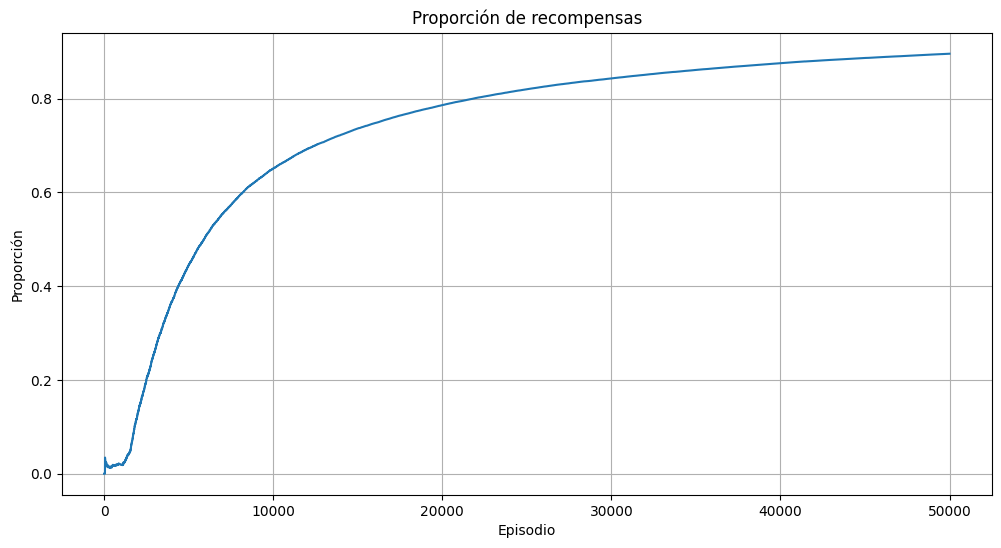

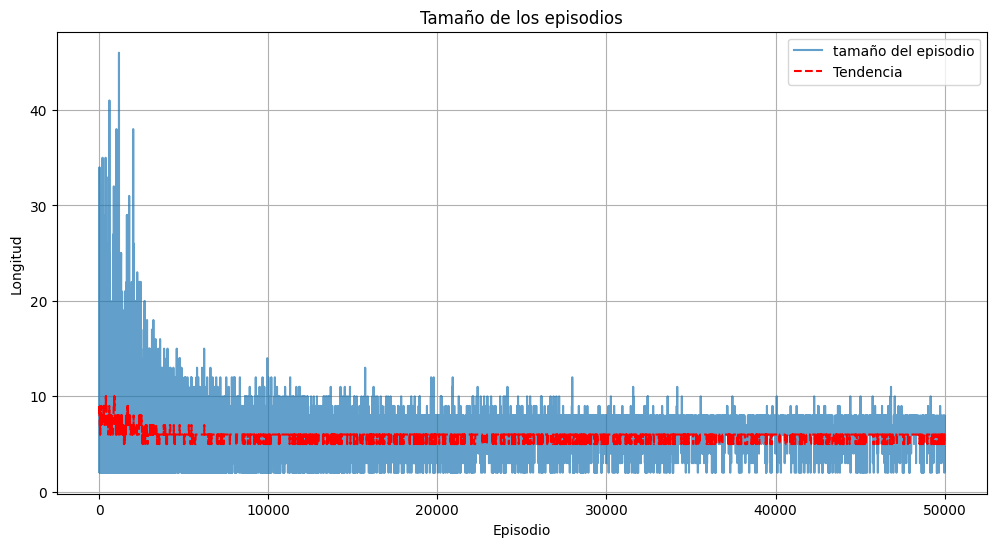

Máxima proporcion: 0.89594


In [ ]:
#@title Proporción de aciertos por número de episodios

plot(list_stats)
plot_episode_lengths(episode_lengths)
#plot_episode_length_vs_time(episode_lengths)
print(f"Máxima proporcion: {list_stats[-1]}")

####.
Mostramos los valores Q para cada estado. Cada estado tienen 4 valores, que se corresponden con las 4 acciones que se pueden en cada estado.

In [ ]:
# @title Tabla de valores Q
LEFT, DOWN, RIGHT, UP = 0,1,2,3
print("Valores Q para cada estado:\n", Q)


Valores Q para cada estado:
 [[0.27739913 0.         0.64588007 0.25313966]
 [0.36624405 0.         0.73499586 0.40332656]
 [0.43911955 0.76981595 0.45746572 0.51368097]
 [0.56216973 0.         0.21045365 0.22070815]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.88882821 0.         0.60358023]
 [0.         0.         0.         0.        ]
 [0.31225758 0.         0.66595619 0.        ]
 [0.49447247 0.86788322 0.63412866 0.        ]
 [0.74048341 0.97522855 0.         0.69651223]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.71034401 0.96082912 0.73470253]
 [0.8756989  0.9481808  1.         0.82755513]
 [0.         0.         0.         0.        ]]


- También se muestra la política óptima (greedy) obtenida a partir del aprendizaje anterior.

- Cada estado tienen 4 valores, pero todos son 0 menos 1. Es decir, en cada estado se aplica de manera determinística una única acción.

*TODO:* Mostrar de forma gráfica el escenario.

In [ ]:
from pyvirtualdisplay import Display

# visible=0 indica que la pantalla estará oculta (no visible para el usuario).
# Esto se debe a que Colab se ejecuta en un entorno de servidor sin una interfaz gráfica.
# size=(1400, 900) establece la resolución de la pantalla virtual a 1400x900 píxeles.
display = Display(visible=0, size=(1400, 900))

# inicia la pantalla virtual, preparándola para su uso.
display.start()


# Las siguientes líneas importan las bibliotecas necesarias para trabajar
# con entrada/salida, codificación base64 (usada para incrustar datos de video)
# y mostrar contenido HTML dentro del notebook de Colab.
import io
import base64
from IPython import display
from IPython.display import HTML

# Esta función mostrará un vídelo en la pantalla virtual, que será embembida en el notbook
def embed_video(video_file):
    # open and read the raw data from the video
    video_data = io.open(video_file, 'r+b').read()
    # now we have to encode the data into base64 to work
    # with the virtual display
    encoded_data = base64.b64encode(video_data)
    # now we use the display.display function to take some html
    # and the encoded data and embed the html into the notebook!
    display.display(HTML(data=''''''.format(encoded_data.decode('ascii'))))

In [ ]:

import re # Para trabajar con expresiones regulares
import os # Para manipular archivos, directorios, variables de entorno y ejecutar comandos del SO

# Define la carpeta donde se guardarán los vídeos
video_folder = "mis_videos"  # Nombre de la carpeta (puedes cambiarlo)

# Crea la carpeta si no existe
os.makedirs(video_folder, exist_ok=True) # exist_ok=True evita error si ya existe

# Retorna el nombre del último vídeo generado

def get_latest_episode_video_file(directory):
    # Expresión regular que coincide con el formato de los ficheros de video
    pattern = re.compile(r"rl-video-episode-(\d+)\.mp4")
    latest_file = None
    highest_episode = -1

    # Busca en el directorio
    for filename in os.listdir(directory):
        match = pattern.match(filename)
        if match:
            episode_number = int(match.group(1))  # Extrae el número de episodio
            # Comprobamos, para conseguir el número de episodio más alto.
            if episode_number > highest_episode:
                highest_episode = episode_number
                latest_file = os.path.join(directory, filename)  # Almacena el path completo

    return latest_file


# Esta función mostrará un vídeos en la pantalla virtual, que será embembida en el notbook
def embed_video(video_file):
    # open and read the raw data from the video
    video_data = io.open(video_file, 'r+b').read()
    # now we have to encode the data into base64 to work
    # with the virtual display
    encoded_data = base64.b64encode(video_data)
    # now we use the display.display function to take some html
    # and the encoded data and embed the html into the notebook!
    display.display(HTML(data=''''''.format(encoded_data.decode('ascii'))))


In [ ]:
# @title Política final
pi, actions = pi_star_from_Q_recordVideo(env4, Q, video_folder="mis_videos")


print("Política óptima obtenida\n", pi, f"\n Acciones {actions} \n Para el siguiente grid\n", env4.render())
print()

/usr/local/lib/python3.11/dist-packages/gymnasium/wrappers/rendering.py:283: UserWarning: WARN: Overwriting existing videos at /content/mis_videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


🎥 Grabando episodio 1...
Episodio 1 completado.
🎥 Grabando episodio 1001...
Episodio 1001 completado.
🎥 Grabando episodio 2001...
Episodio 2001 completado.
🎥 Grabando episodio 3001...
Episodio 3001 completado.
🎥 Grabando episodio 4001...
Episodio 4001 completado.
Política óptima obtenida
 [[0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 2. 0.]
 [0. 0. 0. 0.]] 
 Acciones Episodio 4001: 2, 2, 1, 1, 1, 2,  
 Para el siguiente grid
 [[[180 200 230]
  [180 200 230]
  [180 200 230]
  ...
  [180 200 230]
  [180 200 230]
  [180 200 230]]

 [[180 200 230]
  [204 230 255]
  [204 230 255]
  ...
  [204 230 255]
  [204 230 255]
  [180 200 230]]

 [[180 200 230]
  [235 245 249]
  [204 230 255]
  ...
  [204 230 255]
  [204 230 255]
  [180 200 230]]

 ...

 [[180 200 230]
  [235 245 249]
  [235 245 249]
  ...
  [204 230 255]
  [235 245

In [ ]:
latest_file = get_latest_episode_video_file(video_folder)
print(f"Último vídeo: {latest_file}") # outputs: ./video/rl-video-episode-4.mp4
embed_video(latest_file)

Último vídeo: mis_videos/rl-video-episode-0.mp4


### **3.3 Experimentación en el escenario 8x8**

  - Se realizan 5000 epsisodios y se actualizan los valores Q (valor de acción) basándose en las recompensas obtenidas durante cada episodio completo (e.d. aplicamos Monte Carlo) Se apica una política $\epsilon$ greedy sobre una política $\epsilon$ soft con un valor $\epsilon$ decreciente



In [ ]:
# @title Aprendizaje
NUM_EPISODES = 10000
GAMMA = 0.99  # Factor de descuento
EPSILON = 0.4 # Probabilidad de exploración
DECAY = True

agent8 = AgentMonteCarloOnPolicy(
    env=env8,
    gamma=GAMMA,
    epsilon=EPSILON,
    decay = DECAY
)
Q8, list_stats8, episode_lengths8 = on_policy_all_visit(agent8, env8, num_episodes=NUM_EPISODES)

 11%|█         | 1053/10000 [00:03<00:31, 280.07it/s]

Éxito promedio: 0.002, epsilon: 0.9990


 20%|██        | 2035/10000 [00:08<00:28, 282.82it/s]

Éxito promedio: 0.1085, epsilon: 0.4998


 30%|███       | 3021/10000 [00:12<00:32, 217.82it/s]

...

 80%|████████  | 8013/10000 [00:58<00:26, 76.09it/s]

Éxito promedio: 0.657875, epsilon: 0.1250


 90%|█████████ | 9011/10000 [01:14<00:14, 67.50it/s]

Éxito promedio: 0.6882222222222222, epsilon: 0.1111


100%|██████████| 10000/10000 [01:31<00:00, 108.92it/s]


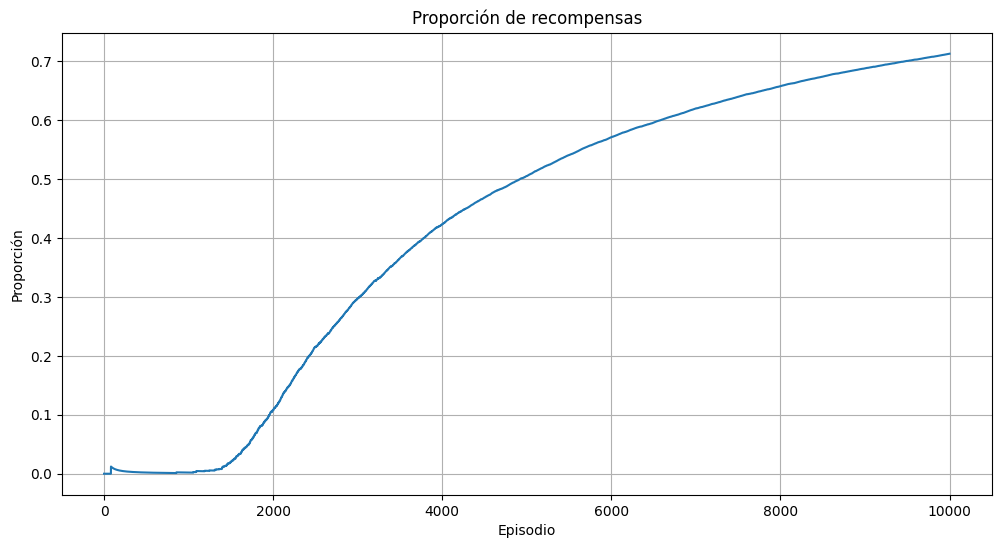

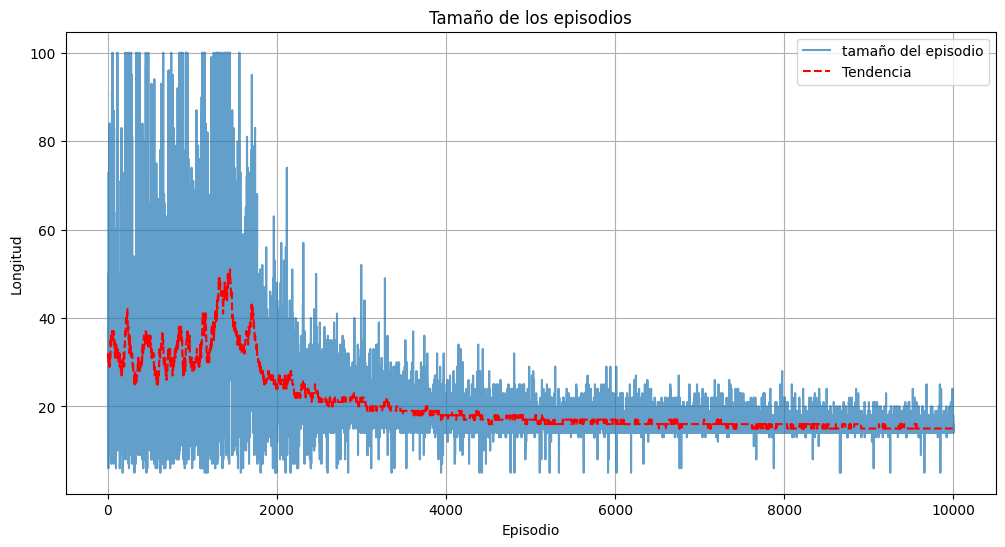

Máxima proporcion: 0.7129


In [ ]:
#@title Proporción de aciertos por número de episodios

plot(list_stats8)
plot_episode_lengths(episode_lengths8)
#plot_episode_length_vs_time(episode_lengths)
print(f"Máxima proporcion: {list_stats8[-1]}")

####.
Mostramos los valores Q para cada estado. Cada estado tienen 4 valores, que se corresponden con las 4 acciones que se pueden en cada estado.

In [ ]:
# @title Tabla de valores Q
LEFT, DOWN, RIGHT, UP = 0,1,2,3
print("Valores Q para cada estado:\n", Q8)

Valores Q para cada estado:
 [[0.24561671 0.22944279 0.62798256 0.24232126]
 [0.28848738 0.26872282 0.65443681 0.29729229]
 [0.3399598  0.3086374  0.68848382 0.33654089]
 [0.4176893  0.36062196 0.71971948 0.4420784 ]
 [0.48160397 0.48546969 0.74072666 0.49344908]
 [0.51936669 0.51821944 0.76184677 0.5510241 ]
 [0.56719716 0.57163089 0.7804692  0.6018001 ]
 [0.58535051 0.78943312 0.62076869 0.60752419]
 [0.05556732 0.06613468 0.06355124 0.2964639 ]
 [0.06600037 0.05029828 0.05431594 0.31342253]
 [0.09165192 0.06793225 0.33299909 0.0769481 ]
 [0.15975718 0.         0.50507039 0.18314242]
 [0.22163432 0.15189493 0.2818276  0.61495203]
 [0.20738998 0.55483083 0.26569059 0.24378837]
 [0.29906323 0.35187156 0.65765959 0.32562531]
 [0.60446227 0.79857813 0.608206   0.60032542]
 [0.02366761 0.01609775 0.02712119 0.10204679]
 [0.06166081 0.00988655 0.01911971 0.02388445]
 [0.02094365 0.01588088 0.         0.12006875]
 [0.         0.         0.         0.        ]
 [0.         0.1027271  0.32256

- También se muestra la política óptima (greedy) obtenida a partir del aprendizaje anterior.

- Cada estado tienen 4 valores, pero todos son 0 menos 1. Es decir, en cada estado se aplica de manera determinística una única acción.

*TODO:* Mostrar de forma gráfica el escenario.

In [ ]:
# @title Política final
LEFT, DOWN, RIGHT, UP = 0,1,2,3
pi, actions = pi_star_from_Q_recordVideo(env8, Q8, video_folder="mis_videos")

print("Política óptima obtenida\n", pi, f"\n Acciones {actions} \n Para el siguiente grid\n", env8.render())
print()

/usr/local/lib/python3.11/dist-packages/gymnasium/wrappers/rendering.py:283: UserWarning: WARN: Overwriting existing videos at /content/mis_videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


🎥 Grabando episodio 1...
Episodio 1 completado.
🎥 Grabando episodio 1001...
Episodio 1001 completado.
🎥 Grabando episodio 2001...
Episodio 2001 completado.
🎥 Grabando episodio 3001...
Episodio 3001 completado.
🎥 Grabando episodio 4001...
Episodio 4001 completado.
Política óptima obtenida
 [[0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 

In [ ]:
latest_file = get_latest_episode_video_file(video_folder)
print(f"Último vídeo: {latest_file}") # outputs: ./video/rl-video-episode-4.mp4
embed_video(latest_file)

Último vídeo: mis_videos/rl-video-episode-0.mp4


## **4. Análisis y Estudios Futuros**

### **4.1 Análisis de Resultados**

- En los dos entornos (4x4 y 8x8), el agente comienza con un conocimiento muy limitado, pero gradualmente mejora su desempeño a medida que avanza en los episodios. Este comportamiento se puede observar en el gráfico de la proporción de recompensas, que aumenta con el tiempo.
- En el entorno 4x4, la máxima proporción de éxito alcanzada fue 0.522, mientras que en el entorno 8x8, la máxima alcanzada fue 0.914. Esto refleja que el agente aprendió a optimizar su estrategia en un entorno más complejo.
- La política óptima obtenida muestra las acciones recomendadas por el agente en cada estado del entorno. En el entorno 8x8, la política es más compleja debido a la mayor cantidad de estados y la dificultad del entorno.

### **4.2 Propuestas para Estudios Futuros**

1. **Evaluar con Otros Entornos**: Sería interesante aplicar este algoritmo a otros entornos más complejos de `gym`, como "Taxi-v3" o "MountainCar", para analizar cómo se comporta el agente en situaciones con dinámicas más complicadas.
   
2. **Optimización del Decaimiento de Epsilon**: Aunque se utilizó un decaimiento de epsilon en el segundo experimento, se podría investigar la efectividad de diferentes tasas de decaimiento o incluso explorar algoritmos como `Q-learning` para comparar su desempeño. Graficamente se trataría de mostrar la curva de la tasa de aciertos para distintas funciones de decaimientos

3. **Análisis del Impacto de los descuentos en las Recompensas**: El estudio se ha hecho para $\gamma = 1$; pero no se ha probado qué pasa cuando  $0 \leq \gamma < 1$. Se trataría de estudiar la curva para distintos valores de $\gamma$

4. **Nuevas gráficas**: Aquí solo se ha usado la proporción de aciertos, pero sería interesante qué relación entre dicha tasa y las tamaños de los episodios.

4. **Ampliación del Algoritmo**: Explorar otros enfoques de Monte Carlo o incluso combinar Monte Carlo con otros algoritmos de aprendizaje por refuerzo, como el Deep Q-Network (DQN), podría mejorar aún más los resultados en entornos más complejos.


# MONTE CARLO OFF-POLICY

In [ ]:
import gymnasium as gym
import numpy as np
from tqdm import tqdm


# Clase MonteCarloOffPolicyAgent
class AgentMonteCarloOffPolicy:
    def __init__(self, env, gamma, epsilon, decay):
        self.env = env
        self.gamma = gamma
        self.epsilon = epsilon
        self.decay = decay

        self.Q = np.zeros((self.env.observation_space.n, self.env.action_space.n))
        self.C = np.zeros((self.env.observation_space.n, self.env.action_space.n))
        self.returns = {}  # Diccionario para almacenar los retornos de cada par (estado, acción)


    # Política ε-soft
    def get_action(self, state, n):
        if self.decay:
            self.epsilon = min(1.0, 1000.0/(n+1))
        action_probabilities = np.ones(self.env.action_space.n) * (self.epsilon / self.env.action_space.n)
        best_action = np.argmax(self.Q[state])
        action_probabilities[best_action] += (1 - self.epsilon)

        return np.random.choice(self.env.action_space.n, p=action_probabilities)


    # Actualizar la tabla Q usando Monte Carlo On-Policy
    def update(self, episode):
        G = 0  # Retorno total
        W = 1  # Peso de Importance Sampling

        # Recorrer el episodio en reversa
        for t in range(len(episode) - 1, -1, -1):
            state, action, reward = episode[t]
            G = self.gamma * G + reward
            self.C[state, action] += W
            self.Q[state, action] += (W / self.C[state, action]) * (G - self.Q[state, action])

            # Si la acción no es la óptima según la política objetivo, terminar el episodio
            if action != np.argmax(self.Q[state]):
                break

            W = W * 1.0 / (self.epsilon / self.env.action_space.n + (1 - self.epsilon) * (action == np.argmax(self.Q[state])))


In [ ]:
NUM_EPISODES = 10000
GAMMA = 0.99  # Factor de descuento
EPSILON = 0.4 # Probabilidad de exploración
DECAY = True

agent4_off = AgentMonteCarloOffPolicy(
    env=env4,
    gamma=GAMMA,
    epsilon=EPSILON,
    decay = DECAY

)

Q, list_stats, episode_lengths = on_policy_all_visit(agent4_off, env4, num_episodes=NUM_EPISODES)

 13%|█▎        | 1251/10000 [00:00<00:03, 2866.11it/s]

Éxito promedio: 0.004, epsilon: 0.9990


 22%|██▏       | 2213/10000 [00:01<00:04, 1683.82it/s]

Éxito promedio: 0.049, epsilon: 0.4998


 32%|███▏      | 3233/10000 [00:01<00:05, 1202.59it/s]

...

 82%|████████▏ | 8227/10000 [00:04<00:00, 1800.18it/s]

Éxito promedio: 0.521375, epsilon: 0.1250


 92%|█████████▏| 9195/10000 [00:05<00:00, 1884.00it/s]

Éxito promedio: 0.5578888888888889, epsilon: 0.1111


100%|██████████| 10000/10000 [00:05<00:00, 1716.39it/s]


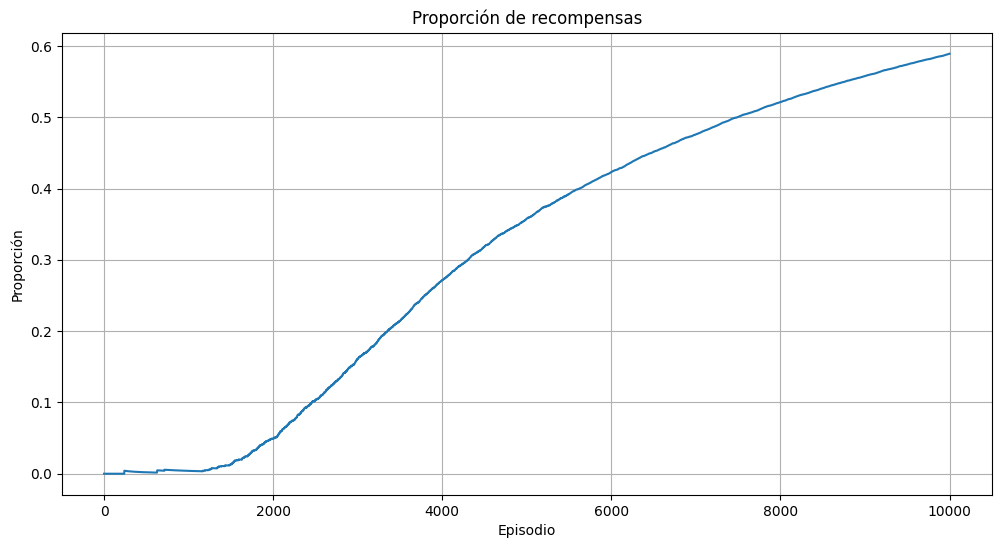

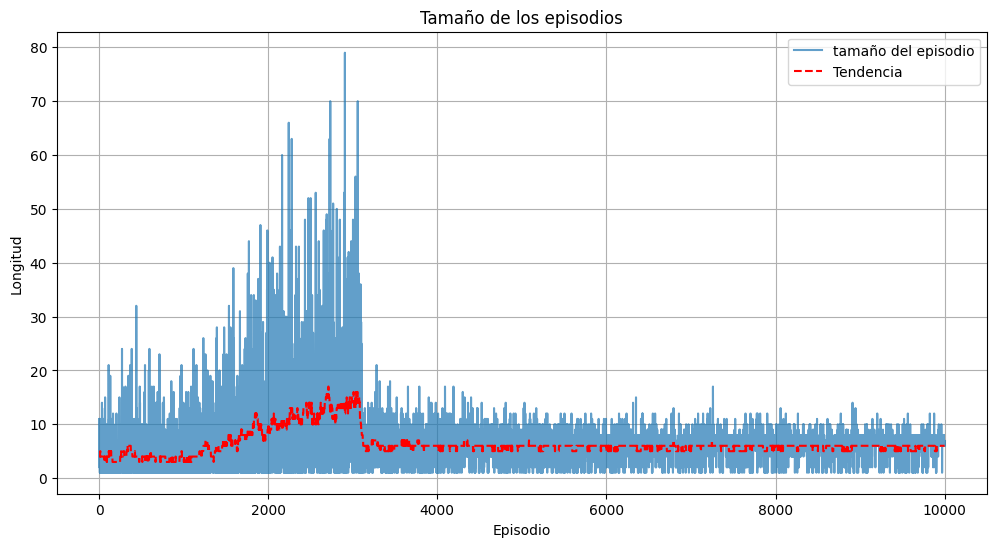

Máxima proporcion: 0.5891


In [ ]:
plot(list_stats)
plot_episode_lengths(episode_lengths)
#plot_episode_length_vs_time(episode_lengths)
print(f"Máxima proporcion: {list_stats[-1]}")

In [ ]:
pi, actions = pi_star_from_Q_recordVideo(env4, Q, video_folder="mis_videos")


print("Política óptima obtenida\n", pi, f"\n Acciones {actions} \n Para el siguiente grid\n", env4.render())
print()

/usr/local/lib/python3.11/dist-packages/gymnasium/wrappers/rendering.py:283: UserWarning: WARN: Overwriting existing videos at /content/mis_videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


🎥 Grabando episodio 1...
Episodio 1 completado.
🎥 Grabando episodio 1001...
Episodio 1001 completado.
🎥 Grabando episodio 2001...
Episodio 2001 completado.
🎥 Grabando episodio 3001...
Episodio 3001 completado.
🎥 Grabando episodio 4001...
Episodio 4001 completado.
Política óptima obtenida
 [[0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 2. 0.]
 [0. 0. 0. 0.]] 
 Acciones Episodio 4001: 2, 2, 1, 1, 1, 2,  
 Para el siguiente grid
 [[[180 200 230]
  [180 200 230]
  [180 200 230]
  ...
  [180 200 230]
  [180 200 230]
  [180 200 230]]

 [[180 200 230]
  [204 230 255]
  [204 230 255]
  ...
  [204 230 255]
  [204 230 255]
  [180 200 230]]

 [[180 200 230]
  [235 245 249]
  [204 230 255]
  ...
  [204 230 255]
  [204 230 255]
  [180 200 230]]

 ...

 [[180 200 230]
  [235 245 249]
  [235 245 249]
  ...
  [204 230 255]
  [235 245

In [ ]:
latest_file = get_latest_episode_video_file(video_folder)
print(f"Último vídeo: {latest_file}") # outputs: ./video/rl-video-episode-4.mp4
embed_video(latest_file)

Último vídeo: mis_videos/rl-video-episode-4.mp4


# Sarsa

In [ ]:
import gymnasium as gym
import numpy as np
from tqdm import tqdm


class AgentSarsa:
    def __init__(self, env, gamma, epsilon, decay, alpha):
        self.env = env
        self.gamma = gamma
        self.epsilon = epsilon
        self.decay = decay
        self.alpha = alpha

        self.Q = np.zeros((self.env.observation_space.n, self.env.action_space.n))
        self.returns = {}  # Diccionario para almacenar los retornos de cada par (estado, acción)


    # Política ε-soft
    def get_action(self, state, n):
        if self.decay:
            self.epsilon = min(1.0, 1000.0/(n+1))
        action_probabilities = np.ones(self.env.action_space.n) * (self.epsilon / self.env.action_space.n)
        best_action = np.argmax(self.Q[state])
        action_probabilities[best_action] += (1 - self.epsilon)

        return np.random.choice(self.env.action_space.n, p=action_probabilities)


    def update(self, state, action, reward, next_state, next_action, terminated, truncated):
          """
          Actualiza la tabla Q usando el algoritmo SARSA basado en un solo episodio.
          """
          if terminated or truncated:
              self.Q[state, action] += self.alpha * (reward - self.Q[state, action])
          else:
              self.Q[state, action] += self.alpha * (
                  reward + self.gamma * self.Q[next_state, next_action] - self.Q[state, action]
              )



In [ ]:
#@title Algoritmo de Iteración de Valor versión MC con Políticas epsilon-soft

def on_policy_all_visit_sarsa(agent, env, num_episodes=5000):
    """
    Algoritmo SARSA on-policy con una política epsilon-soft.
    """
    # Para mostrar la evolución
    stats = 0.0
    list_stats = [stats]
    episode_lengths = []
    step_display = max(1, num_episodes // 10)

    for t in tqdm(range(num_episodes), disable=False):
        state, info = env.reset(seed=100)
        action = agent.get_action(state, t)  # Elegir A usando la política derivada de Q
        done = False
        result_sum = 0.0  # Retorno
        length = 0  # Longitud del episodio

        while not done:
            next_state, reward, terminated, truncated, info = env.step(action)
            next_action = agent.get_action(next_state, t) if not (terminated or truncated) else None

            agent.update(state, action, reward, next_state, next_action, terminated, truncated)

            state, action = next_state, next_action  # S <- S'; A <- A'
            done = terminated or truncated
            result_sum += reward
            length += 1

        episode_lengths.append(length)

        # Guardamos datos sobre la evolución
        stats += result_sum
        list_stats.append(stats / (t + 1))

        # Mostrar información periódicamente
        if t % step_display == 0 and t != 0:
            print(f"Éxito promedio: {stats/t}, epsilon: {agent.epsilon:.4f}")

    return agent.Q, list_stats, episode_lengths



In [ ]:
NUM_EPISODES = 50000
GAMMA = 0.99  # Factor de descuento
EPSILON = 0.4 # Probabilidad de exploración
DECAY = True

agent4_sarsa = AgentSarsa(
    env=env4,
    gamma=GAMMA,
    epsilon=EPSILON,
    decay = DECAY,
    alpha = 0.5 #Probar este valor como en las diapositivas

)

Q_sarsa, list_stats_sarsa, episode_lengths_sarsa = on_policy_all_visit_sarsa(agent4_sarsa, env4, num_episodes=NUM_EPISODES)

 11%|█         | 5300/50000 [00:02<00:25, 1744.55it/s]

Éxito promedio: 0.3662, epsilon: 0.2000


 20%|██        | 10198/50000 [00:05<00:23, 1694.35it/s]

Éxito promedio: 0.5822, epsilon: 0.1000


 30%|███       | 15156/50000 [00:07<00:19, 1760.80it/s]

...

 81%|████████  | 40399/50000 [00:21<00:03, 2471.53it/s]

Éxito promedio: 0.84305, epsilon: 0.0250


 90%|█████████ | 45242/50000 [00:24<00:03, 1420.87it/s]

Éxito promedio: 0.8568666666666667, epsilon: 0.0222


100%|██████████| 50000/50000 [00:26<00:00, 1899.16it/s]


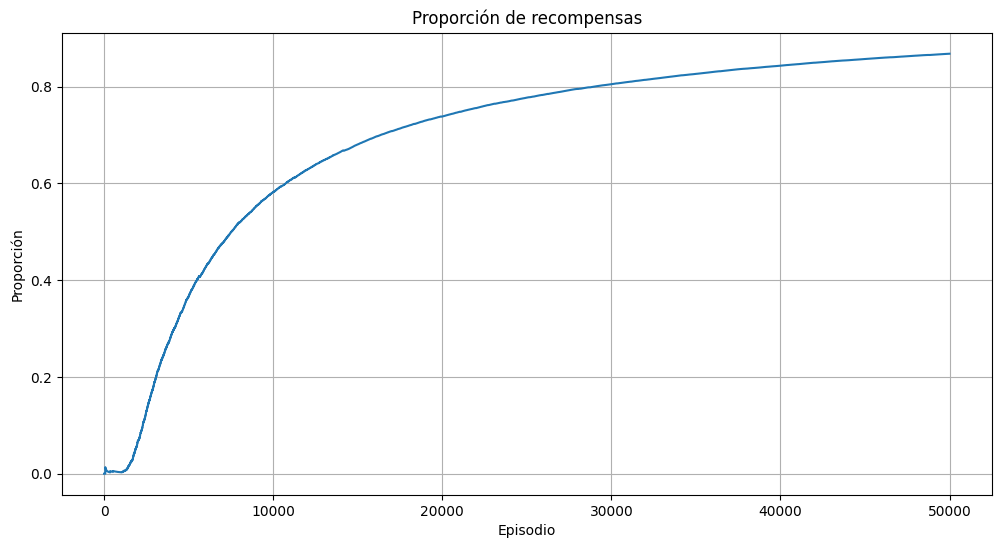

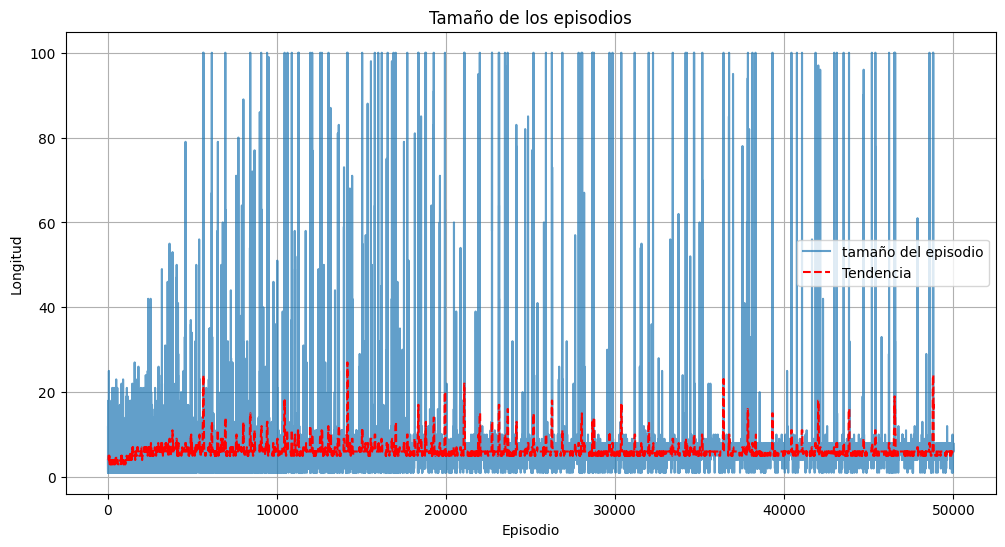

Máxima proporcion: 0.86778


In [ ]:
plot(list_stats_sarsa)
plot_episode_lengths(episode_lengths_sarsa)
#plot_episode_length_vs_time(episode_lengths)
print(f"Máxima proporcion: {list_stats_sarsa[-1]}")

In [ ]:
pi, actions = pi_star_from_Q_recordVideo(env4, Q_sarsa, video_folder="mis_videos")


print("Política óptima obtenida\n", pi, f"\n Acciones {actions} \n Para el siguiente grid\n", env4.render())
print()

Grabando episodio 1...
Episodio 1 completado.


/usr/local/lib/python3.11/dist-packages/gymnasium/wrappers/rendering.py:283: UserWarning: WARN: Overwriting existing videos at /content/mis_videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Grabando episodio 1001...
Episodio 1001 completado.
Grabando episodio 2001...
Episodio 2001 completado.
Grabando episodio 3001...
Episodio 3001 completado.
Grabando episodio 4001...
Episodio 4001 completado.
Política óptima obtenida
 [[0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 2. 0.]
 [0. 0. 0. 0.]] 
 Acciones Episodio 4001: 2, 2, 1, 1, 1, 2,  
 Para el siguiente grid
 [[[180 200 230]
  [180 200 230]
  [180 200 230]
  ...
  [180 200 230]
  [180 200 230]
  [180 200 230]]

 [[180 200 230]
  [204 230 255]
  [204 230 255]
  ...
  [204 230 255]
  [204 230 255]
  [180 200 230]]

 [[180 200 230]
  [235 245 249]
  [204 230 255]
  ...
  [204 230 255]
  [204 230 255]
  [180 200 230]]

 ...

 [[180 200 230]
  [235 245 249]
  [235 245 249]
  ...
  [204 230 255]
  [235 245 249]
  [180 200 230]]

 [[180 200 230]
  [235 245 249]


In [ ]:
latest_file = get_latest_episode_video_file(video_folder)
print(f"Último vídeo: {latest_file}") # outputs: ./video/rl-video-episode-4.mp4
embed_video(latest_file)

Último vídeo: mis_videos/rl-video-episode-4.mp4


# Q-Learning

In [ ]:
import gymnasium as gym
import numpy as np
from tqdm import tqdm


class AgentQLearning:
    def __init__(self, env, gamma, epsilon, decay, alpha):
        self.env = env
        self.gamma = gamma
        self.epsilon = epsilon
        self.decay = decay
        self.alpha = alpha

        self.Q = np.zeros((self.env.observation_space.n, self.env.action_space.n))
        self.returns = {}  # Diccionario para almacenar los retornos de cada par (estado, acción)


    # Política ε-soft
    def get_action(self, state, n):
        if self.decay:
            self.epsilon = min(1.0, 1000.0/(n+1))
        action_probabilities = np.ones(self.env.action_space.n) * (self.epsilon / self.env.action_space.n)
        best_action = np.argmax(self.Q[state])
        action_probabilities[best_action] += (1 - self.epsilon)

        return np.random.choice(self.env.action_space.n, p=action_probabilities)


    def update(self, state, action, reward, next_state, terminated, truncated):
        """
        Actualiza la tabla Q usando el algoritmo Q-learning basado en un solo episodio.
        """
        if terminated or truncated:
            self.Q[state, action] += self.alpha * (reward - self.Q[state, action])
        else:
            self.Q[state, action] += self.alpha * (
                reward + self.gamma * np.max(self.Q[next_state]) - self.Q[state, action]
            )



In [ ]:
def on_policy_all_visit_Qlearning(agent, env, num_episodes=5000):
    """
    Algoritmo SARSA on-policy con una política epsilon-soft.
    """
    # Para mostrar la evolución
    stats = 0.0
    list_stats = [stats]
    episode_lengths = []
    step_display = max(1, num_episodes // 10)

    for t in tqdm(range(num_episodes), disable=False):
        state, info = env.reset(seed=100)
        action = agent.get_action(state, t)  # Elegir A usando la política derivada de Q
        done = False
        result_sum = 0.0  # Retorno
        length = 0  # Longitud del episodio

        while not done:
            action = agent.get_action(state, t)
            next_state, reward, terminated, truncated, info = env.step(action)

            agent.update(state, action, reward, next_state, terminated, truncated)

            state = next_state # S <- S'
            done = terminated or truncated
            result_sum += reward
            length += 1

        episode_lengths.append(length)

        # Guardamos datos sobre la evolución
        stats += result_sum
        list_stats.append(stats / (t + 1))

        # Mostrar información periódicamente
        if t % step_display == 0 and t != 0:
            print(f"Éxito promedio: {stats/t}, epsilon: {agent.epsilon:.4f}")

    return agent.Q, list_stats, episode_lengths


In [ ]:
NUM_EPISODES = 100000
GAMMA = 0.99  # Factor de descuento
EPSILON = 1 # Probabilidad de exploración
DECAY = True

agent4_qle = AgentQLearning(
    env=env4,
    gamma=GAMMA,
    epsilon=EPSILON,
    decay = DECAY,
    alpha = 0.2 #Probar este valor como en las diapositivas

)

Q_qle, list_stats_qle, episode_lengths_qle = on_policy_all_visit_Qlearning(agent4_qle, env4, num_episodes=NUM_EPISODES)

 10%|█         | 10409/100000 [00:05<00:41, 2141.73it/s]

Éxito promedio: 0.6091, epsilon: 0.1000


 20%|██        | 20419/100000 [00:10<00:36, 2189.52it/s]

Éxito promedio: 0.7577, epsilon: 0.0500


 30%|███       | 30356/100000 [00:14<00:31, 2208.16it/s]

...

 80%|████████  | 80210/100000 [00:39<00:08, 2279.80it/s]

Éxito promedio: 0.917575, epsilon: 0.0125


 90%|█████████ | 90309/100000 [00:44<00:04, 2213.85it/s]

Éxito promedio: 0.9252333333333334, epsilon: 0.0111


100%|██████████| 100000/100000 [00:49<00:00, 2038.01it/s]


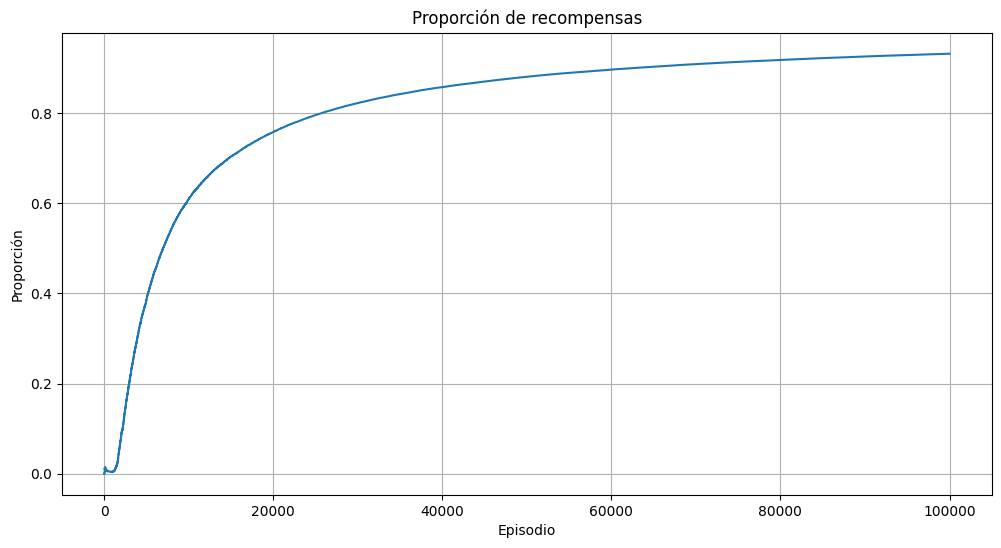

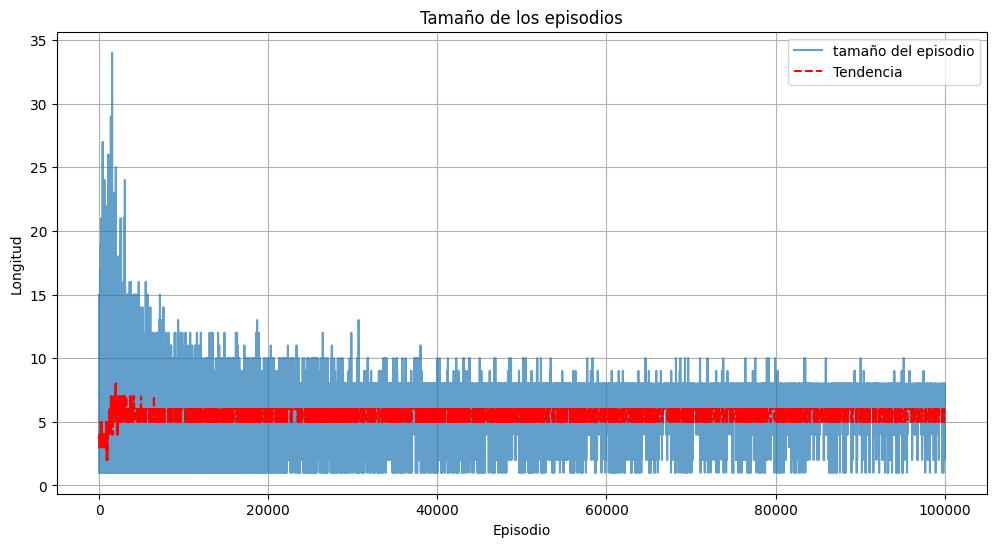

Máxima proporcion: 0.93136


In [ ]:
plot(list_stats_qle)
plot_episode_lengths(episode_lengths_qle)
#plot_episode_length_vs_time(episode_lengths)
print(f"Máxima proporcion: {list_stats_qle[-1]}")

In [ ]:
pi, actions = pi_star_from_Q_recordVideo(env4, Q_qle, video_folder="mis_videos")


print("Política óptima obtenida\n", pi, f"\n Acciones {actions} \n Para el siguiente grid\n", env4.render())
print()

In [ ]:
latest_file = get_latest_episode_video_file(video_folder)
print(f"Último vídeo: {latest_file}") # outputs: ./video/rl-video-episode-4.mp4
embed_video(latest_file)